## 2. Tekstexploratie: Woordanalyse

### 2.1 Packages importeren 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from collections import Counter
from itertools import combinations

from helpfuncties import (
    load_dataset,
    get_all_tokens,
    get_tokens_for_product
)
from preprocessing import spacy_tokenizer
from sklearn.feature_extraction.text import TfidfVectorizer

### 2.2 Dataset inladen 
Alleen de kolommen "Omschrijving" en "Product" worden gebruikt voor de modeltraining. "ID", "Datum_ontvangst" en "Antwoord_bedrijf" voegen geen voorspellende waarde toe. 

In [2]:
df = load_dataset()

In [3]:
all_tokens = get_all_tokens(df)

In [4]:
tokens_per_product = {
    product: get_tokens_for_product(df, product)
    for product in df['Product'].unique()
}

### 2.3 Globale woordfrequenties (sanity check)

In [5]:
Counter(all_tokens).most_common(20)

[('credit', 20428),
 ('account', 20260),
 ('payment', 14497),
 ('report', 12749),
 ('pay', 11741),
 ('loan', 10210),
 ('bank', 9839),
 ('tell', 9631),
 ('receive', 9564),
 ('call', 9476),
 ('time', 8929),
 ('debt', 8773),
 ('send', 8084),
 ('information', 7283),
 ('company', 7275),
 ('card', 7235),
 ('mortgage', 6913),
 ('say', 6359),
 ('letter', 6278),
 ('state', 6242)]

### 2.4 Woordfrequenties per productsector

In [6]:
product_sector_woord_frequenties = {}

for product in df['Product'].unique():
    tokens = tokens_per_product[product]
    word_counts = Counter(tokens)
    product_sector_woord_frequenties[product] = word_counts

In [7]:
freq_tabel = (
    pd.DataFrame(product_sector_woord_frequenties)
    .fillna(0)
    .astype(int)
)

freq_tabel.head()

,Bankrekening,Consumentenkrediet,Creditcard,Hypotheek,Incasso,Kredietregistratie
deposit,1105,46,106,134,89,24
account,5211,886,3578,2480,3814,4291
day,982,550,900,1765,1087,827
different,150,78,188,394,320,182
company,276,522,797,1914,2609,1157


In [8]:
freq_tabel.to_csv("woordfrequenties_per_product.csv")

### 2.5 Meest voorkomende woorden per productsector (tabel)

In [9]:
top_words_per_product = {
    product: Counter(tokens_per_product[product]).most_common(15)
    for product in df['Product'].unique()
}

top_words_df = pd.DataFrame({
    product: [w for w, _ in words]
    for product, words in top_words_per_product.items()
})

top_words_df

,Bankrekening,Consumentenkrediet,Creditcard,Hypotheek,Incasso,Kredietregistratie
0,account,payment,credit,payment,debt,credit
1,bank,loan,card,loan,credit,report
2,check,pay,account,mortgage,account,account
3,tell,credit,payment,pay,call,information
4,fee,car,charge,home,collection,dispute
5,money,account,pay,receive,report,remove
6,charge,call,bank,time,pay,equifax
7,card,tell,tell,tell,company,file
8,deposit,time,receive,bank,receive,experian
9,receive,report,call,send,tell,send


### 2.6 Relatieve woordfrequenties (onderscheidende woorden)

In [10]:
rel_freq = freq_tabel.div(freq_tabel.sum(axis=0), axis=1)

In [11]:
rel_freq['Incasso'].sort_values(ascending=False).head(15)

debt           0.030195
credit         0.019917
account        0.017253
call           0.015801
collection     0.014733
report         0.014430
pay            0.012580
company        0.011802
receive        0.010866
tell           0.009898
send           0.009730
time           0.008527
letter         0.008093
number         0.008088
information    0.008070
Name: Incasso, dtype: float64

In [ ]:
tfidf_tmp = TfidfVectorizer(
    tokenizer=spacy_tokenizer,
    preprocessor=None,
    max_features=20
)

X_tfidf = tfidf_tmp.fit_transform(df["Omschrijving"])

tfidf_words = pd.DataFrame({
    "woord": tfidf_tmp.get_feature_names_out(),
    "idf": tfidf_tmp.idf_
}).sort_values("idf")

tfidf_words

c:\Users\odess\Desktop\ADSAI\Dataproject 1\Dataproject1_Code\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,woord,idf
5,credit,1.668812
0,account,1.804774
14,report,1.998693
11,pay,2.012344
19,time,2.039454
13,receive,2.057361
2,call,2.081151
18,tell,2.157404
12,payment,2.187927
16,send,2.205346


### 2.7 Woorden met hoge overlap tussen sectoren

In [13]:
overlap_counts = (freq_tabel > 0).sum(axis=1)
overlap_counts.sort_values(ascending=False).head(20)

deposit           6
account           6
representative    6
fact              6
come              6
speak             6
guilty            6
authorization     6
violation         6
california        6
law               6
include           6
proceed           6
screen            6
show              6
notice            6
rest              6
get               6
away              6
overdraft         6
dtype: int64

### 2.8 Jaccard overlap

In [14]:
def jaccard(a, b):
    return len(a & b) / len(a | b)

sector_vocab = {
    product: set(tokens_per_product[product])
    for product in df['Product'].unique()
}

In [15]:
jaccard_scores = []

for p1, p2 in combinations(sector_vocab.keys(), 2):
    jaccard_scores.append({
        "sector_1": p1,
        "sector_2": p2,
        "jaccard": round(jaccard(sector_vocab[p1], sector_vocab[p2]), 3)
    })

pd.DataFrame(jaccard_scores).sort_values("jaccard", ascending=False)

,sector_1,sector_2,jaccard
1,Bankrekening,Creditcard,0.433
11,Creditcard,Kredietregistratie,0.404
5,Consumentenkrediet,Creditcard,0.402
0,Bankrekening,Consumentenkrediet,0.398
4,Bankrekening,Kredietregistratie,0.397
10,Creditcard,Incasso,0.390
8,Consumentenkrediet,Kredietregistratie,0.379
3,Bankrekening,Incasso,0.378
14,Incasso,Kredietregistratie,0.378
2,Bankrekening,Hypotheek,0.370


### Conclusie 
De Jaccard-overlap laat zien er veel overlap is voor het woordgebruik tussen de verschillende productsectoren. Dit verklaart waarom sommige sectoren inhoudelijk op elkaar lijken en waarom classificatie tussen bepaalde sectoren moeilijker kan zijn.

### 2.9 WordCloud - alle klachten 

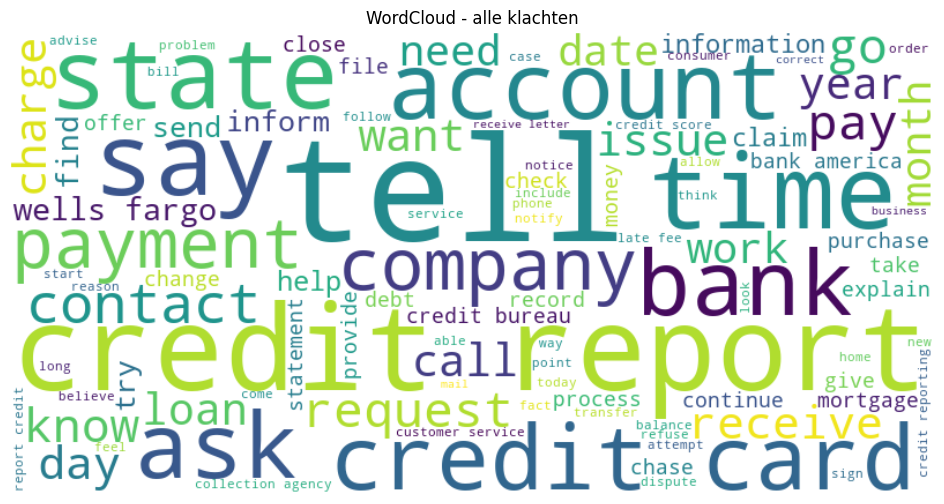

In [16]:
text_blob = " ".join(all_tokens)

wc_all = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(text_blob)

plt.figure(figsize=(12,6))
plt.imshow(wc_all, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - alle klachten")
plt.show()

### 2.10 WordClouds per productsector

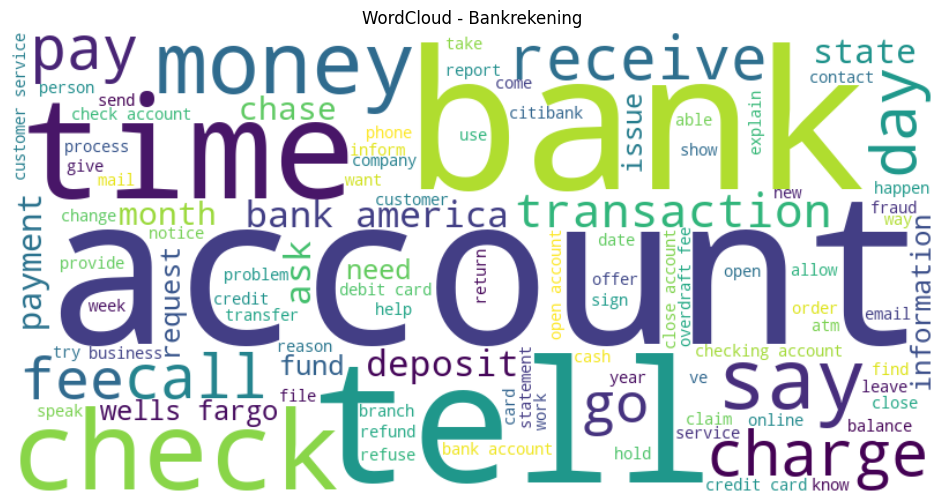

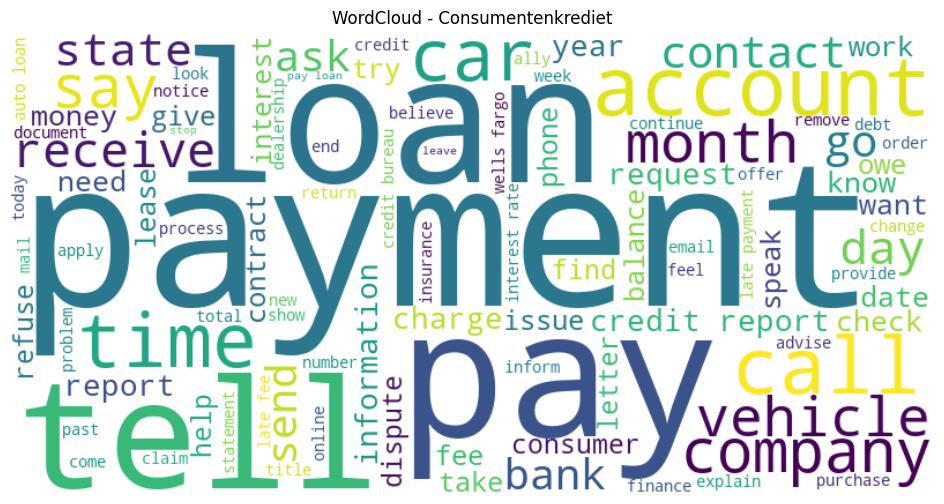

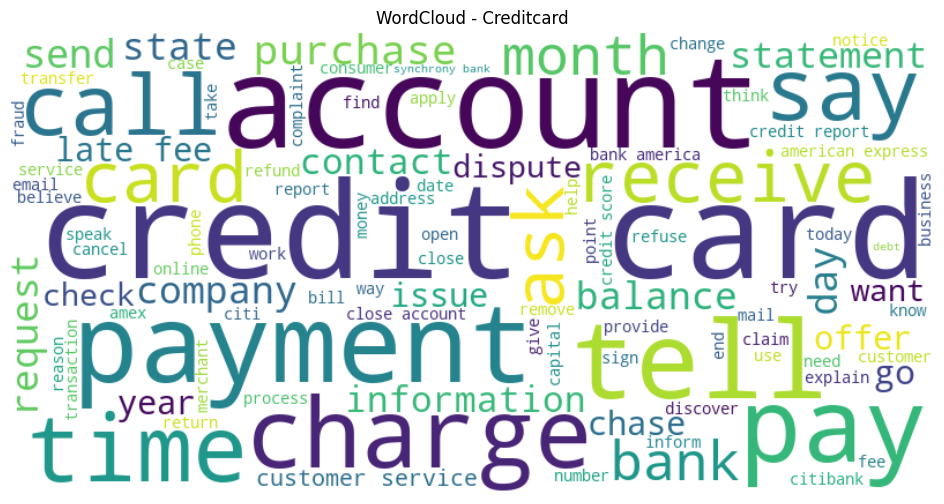

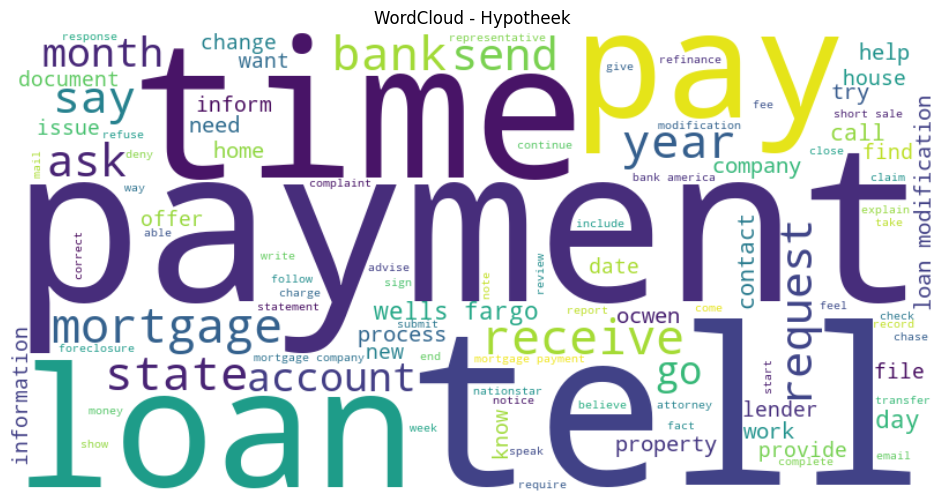

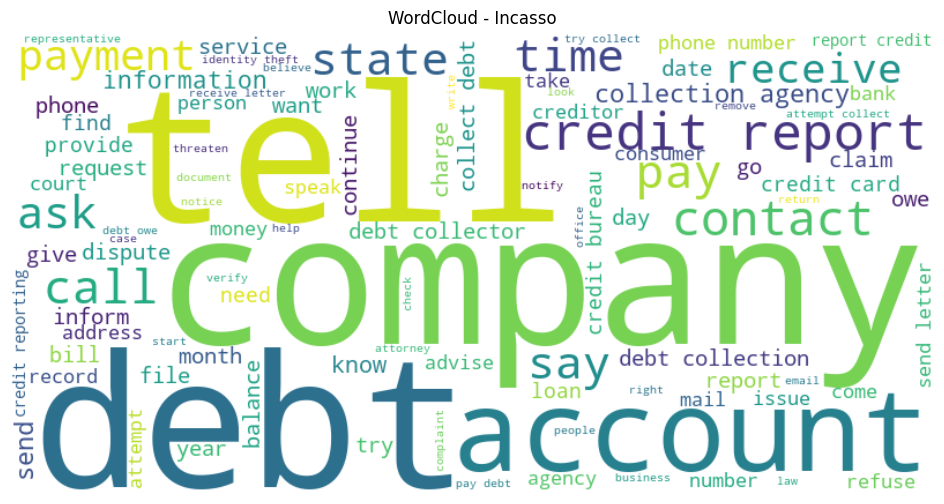

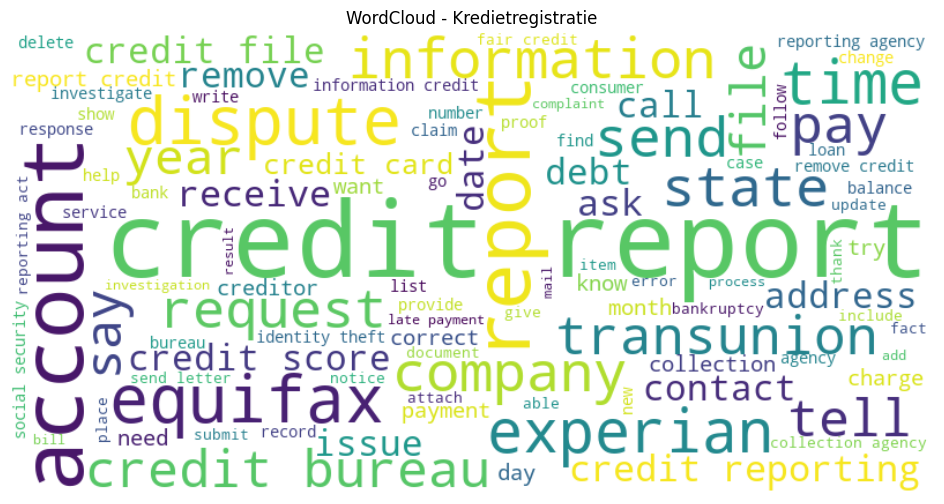

In [17]:
for product in sorted(tokens_per_product):
    tokens = tokens_per_product[product]
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=100
    ).generate(" ".join(tokens))
    
    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(f"WordCloud - {product}")
    plt.axis("off")
    plt.show()

### 2.11 Topwoorden na preprocessing (stopwoorden + lemma)

In [18]:
all_tokens_clean = []

for text in df["Omschrijving"]:
    all_tokens_clean.extend(spacy_tokenizer(text))

Counter(all_tokens_clean).most_common(20)

[('credit', 20428),
 ('account', 20260),
 ('payment', 14497),
 ('report', 12749),
 ('pay', 11741),
 ('loan', 10210),
 ('bank', 9839),
 ('tell', 9631),
 ('receive', 9564),
 ('call', 9476),
 ('time', 8929),
 ('debt', 8773),
 ('send', 8084),
 ('information', 7283),
 ('company', 7275),
 ('card', 7235),
 ('mortgage', 6913),
 ('say', 6359),
 ('letter', 6278),
 ('state', 6242)]

In [19]:
raw_top = Counter(all_tokens).most_common(15)
clean_top = Counter(all_tokens_clean).most_common(15)

pd.DataFrame({
    "raw": [w for w, _ in raw_top],
    "after_preprocessing": [w for w, _ in clean_top]
})

,raw,after_preprocessing
0,credit,credit
1,account,account
2,payment,payment
3,report,report
4,pay,pay
5,loan,loan
6,bank,bank
7,tell,tell
8,receive,receive
9,call,call


In [20]:
clean_tokens_per_product = {
    product: [] for product in df["Product"].unique()
}

for product in df["Product"].unique():
    subset = df.loc[df["Product"] == product, "Omschrijving"]
    for text in subset:
        clean_tokens_per_product[product].extend(
            spacy_tokenizer(text)
        )

In [21]:
top_clean_words = {
    product: Counter(tokens).most_common(10)
    for product, tokens in clean_tokens_per_product.items()
}

pd.DataFrame({
    product: [w for w, _ in words]
    for product, words in top_clean_words.items()
})

,Bankrekening,Consumentenkrediet,Creditcard,Hypotheek,Incasso,Kredietregistratie
0,account,payment,credit,payment,debt,credit
1,bank,loan,card,loan,credit,report
2,check,pay,account,mortgage,account,account
3,tell,credit,payment,pay,call,information
4,fee,car,charge,home,collection,dispute
5,money,account,pay,receive,report,remove
6,charge,call,bank,time,pay,equifax
7,card,tell,tell,tell,company,file
8,deposit,time,receive,bank,receive,experian
9,receive,report,call,send,tell,send
